# Ranking adicional de POIs: uso directo de `score` vs Random Forest

Este notebook desarrolla la siguiente tarea pendiente del Gantt del proyecto:

- Crear un modelo de Ranking Adicional
- Evaluar si conviene usar `score` directamente
- Comparar esa opcion con un modelo adicional, en este caso un `RandomForestRegressor`

La idea de este bloque **no es meter Machine Learning por meter**, sino tomar una decision tecnica coherente con el estado real del proyecto y del dataset.


## Objetivo del notebook

En este notebook vamos a seguir un flujo incremental y explicable:

1. Cargar el dataset procesado
2. Revisar la variable `score`
3. Confirmar si `score` ya puede usarse directamente como senal de ranking
4. Probar un modelo adicional de Random Forest para aproximar `score`
5. Comparar ambas estrategias
6. Cerrar con una conclusion tecnica clara para el sistema hibrido

La hipotesis inicial es la siguiente:

- Si `score` ya esta bien construido y es consistente, puede actuar como ranking principal
- Si el Random Forest solo reaprende una variable derivada sin aportar informacion nueva, no deberia convertirse en el ranking principal


In [1]:
# ==============================
# 1. Carga de librerias
# ==============================

# pandas -> manipulacion de datos
import pandas as pd

# numpy -> operaciones numericas
import numpy as np

# matplotlib y seaborn -> visualizacion basica
import matplotlib.pyplot as plt
import seaborn as sns

# display -> mostrar tablas de forma mas comoda en notebook
from IPython.display import display

# Herramientas de scikit-learn para el experimento con Random Forest
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuracion visual para los graficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [2]:
# ==============================
# 2. Carga de datos
# ==============================

# Cargamos el parquet procesado porque mantiene mejor los tipos de datos
# y es el formato que se ha venido utilizando en los notebooks de modelado.
df = pd.read_parquet('../data/pois_barcelona_procesados.parquet')

# Mostramos dimensiones generales del dataset.
print('Filas y columnas del dataset:', df.shape)

# Mostramos las primeras filas para recordar la estructura.
display(df.head())

# Revisamos las columnas disponibles.
print()
print('Columnas disponibles:')
print(df.columns.tolist())


Filas y columnas del dataset: (775, 21)


,id,name,category,subcategory,latitude,longitude,city,description,rating,match_confidence,...,opening_hours_source,has_opening_hours,is_24_7,is_likely_open,has_match_confidence,score,has_valid_source,visit_duration,tags,tags_str
0,3,Biblioteca de Cataluña,cultural,library,41.3810,2.16951,Barcelona,national library,4.2,0.930000,...,OSM,True,False,True,True,3.21900,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor
1,34,Esquerra de l'Eixample,cultural,library,41.3868,2.15205,Barcelona,neighborhood,4.1,0.503766,...,NaN,False,False,False,False,2.56796,False,60,"[culture, indoor]",culture|indoor
2,35,Can Mariner (Barcelona),cultural,library,41.4312,2.16056,Barcelona,masia,4.1,0.650000,...,OSM,True,False,True,True,3.06500,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor
3,111,Archivo Histórico de la Ciudad de Barcelona,cultural,library,41.3841,2.17567,Barcelona,archive,4.3,0.503766,...,NaN,False,False,False,False,2.68696,False,60,"[culture, indoor]",culture|indoor
4,112,Arxiu Diocesà de Barcelona,cultural,library,41.3837,2.17534,Barcelona,episcopal archive,4.2,0.750000,...,OSM,True,False,True,True,3.16500,True,60,"[culture, has_schedule, indoor]",culture|has_schedule|indoor



Columnas disponibles:
['id', 'name', 'category', 'subcategory', 'latitude', 'longitude', 'city', 'description', 'rating', 'match_confidence', 'opening_hours', 'opening_hours_source', 'has_opening_hours', 'is_24_7', 'is_likely_open', 'has_match_confidence', 'score', 'has_valid_source', 'visit_duration', 'tags', 'tags_str']


## Seleccion de variables relevantes para la fase de ranking

Para esta fase no necesitamos todas las columnas del dataset.
Nos interesan especialmente:

- `score`: senal de ranking ya existente
- `rating`: valoracion del POI
- `match_confidence`: confianza del matching
- `has_match_confidence`: indica si la confianza existia originalmente
- `visit_duration`: posible variable complementaria
- `category` y `subcategory`: para estudiar comportamiento del ranking por tipo de POI

Antes de entrenar ningun modelo, conviene responder una pregunta clave:

> `score` ya existe, pero... es una variable observada independiente o una variable construida dentro del pipeline?


In [3]:
# ==============================
# 3. Verificacion de como se construye score
# ==============================

# En el notebook de limpieza ya se habia definido el score usando:
# - 70% rating
# - 30% match_confidence
# - penalizacion del 15% cuando no habia match_confidence original

# Reconstruimos esa formula directamente para comprobar si el score final
# del dataset coincide exactamente con esa logica.
score_reconstruido = (
    df['rating'] * 0.7 +
    df['match_confidence'] * 0.3
)

# Aplicamos la penalizacion a los casos sin match_confidence original.
score_reconstruido = np.where(
    df['has_match_confidence'] == False,
    score_reconstruido * 0.85,
    score_reconstruido
)

# Calculamos el error absoluto entre el score del dataset y el score reconstruido.
error_absoluto = np.abs(df['score'] - score_reconstruido)

print('Error maximo entre score real y score reconstruido:', error_absoluto.max())
print('Error medio entre score real y score reconstruido:', error_absoluto.mean())
print('Coincidencia exacta:', np.allclose(df['score'], score_reconstruido))


Error maximo entre score real y score reconstruido: 0.0
Error medio entre score real y score reconstruido: 0.0
Coincidencia exacta: True


### Interpretacion de la comprobacion anterior

Si la coincidencia es exacta, entonces el `score`:

- no es una variable externa nueva
- no es una etiqueta independiente creada manualmente despues
- sino una **variable derivada del propio pipeline de limpieza**

Esto es muy importante porque condiciona la decision tecnica:

- usar `score` directamente es razonable, porque ya resume una logica de ranking definida
- entrenar un modelo para predecir `score` implicaria, en gran medida, **reaprender una formula que ya existe**


count    775.000000
mean       2.953729
std        0.316948
min        1.794460
25%        2.746460
50%        2.924960
75%        3.206000
max        3.709000
Name: score, dtype: float64

Correlaciones con score:
score               1.000000
rating              0.641884
match_confidence    0.221591
visit_duration      0.116540
Name: score, dtype: float64


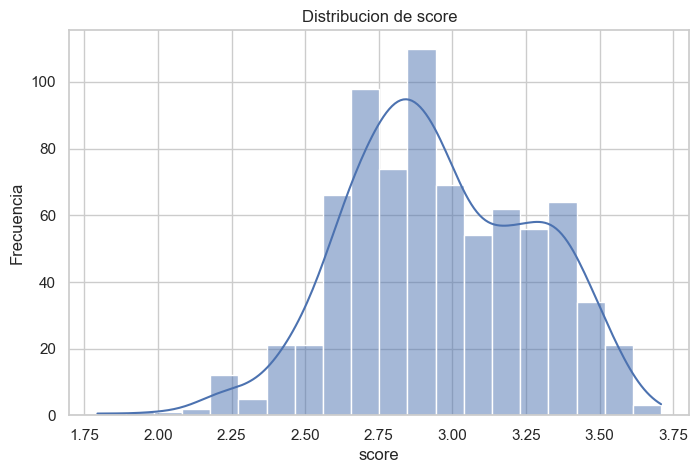

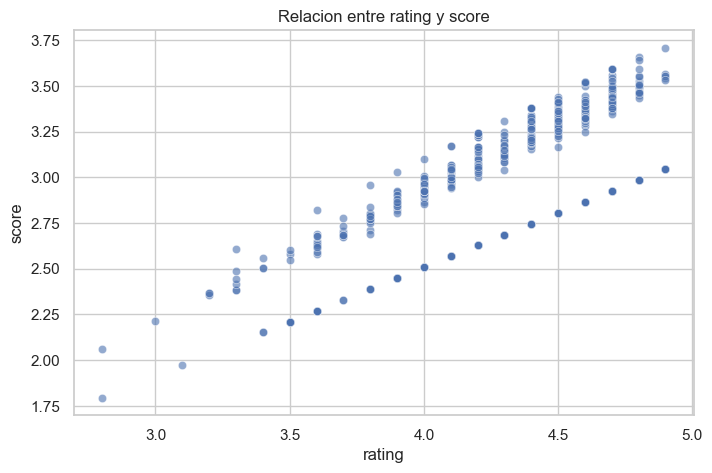

In [4]:
# ==============================
# 4. Analisis descriptivo de score
# ==============================

# Revisamos estadisticos basicos para entender el rango del score.
print(df['score'].describe())

# Comprobamos correlaciones numericas con variables cercanas conceptualmente.
correlaciones = df[['score', 'rating', 'match_confidence', 'visit_duration']].corr(numeric_only=True)
print()
print('Correlaciones con score:')
print(correlaciones['score'].sort_values(ascending=False))

# Visualizamos la distribucion del score.
plt.figure()
sns.histplot(df['score'], bins=20, kde=True)
plt.title('Distribucion de score')
plt.xlabel('score')
plt.ylabel('Frecuencia')
plt.show()

# Visualizamos score frente a rating para ver si existe una dependencia clara.
plt.figure()
sns.scatterplot(data=df, x='rating', y='score', alpha=0.6)
plt.title('Relacion entre rating y score')
plt.xlabel('rating')
plt.ylabel('score')
plt.show()


## Evaluacion de la opcion 1: usar `score` directamente como baseline de ranking

Esta opcion tiene varias ventajas en el estado actual del proyecto:

- es simple y explicable
- ya esta integrada en el dataset procesado
- se alinea con la metodologia incremental del TFG
- evita meter complejidad adicional sin beneficio claro

Ademas, usar `score` directamente permite pasar a la siguiente fase hibrida con una senal de ranking clara y estable.


In [5]:
# ==============================
# 5. Baseline de ranking usando score directo
# ==============================

# Creamos un subconjunto con columnas utiles para ordenar y mostrar resultados.
columnas_ranking = [
    'id',
    'name',
    'category',
    'subcategory',
    'rating',
    'match_confidence',
    'score',
    'visit_duration'
]

# Definimos una funcion sencilla de ranking basada directamente en score.
def rankear_pois_por_score(df_input, categoria=None, min_rating=0.0, top_n=10):
    # Hacemos una copia para no tocar el dataframe original.
    data = df_input.copy()

    # Si se indica categoria, filtramos.
    if categoria is not None:
        data = data[data['category'] == categoria]

    # Filtramos por rating minimo.
    data = data[data['rating'] >= min_rating]

    # Ordenamos de mayor a menor score.
    data = data.sort_values('score', ascending=False)

    # Devolvemos solo las columnas utiles para inspeccion.
    return data[columnas_ranking].head(top_n)

# Mostramos un ejemplo de ranking para la categoria cultural.
ranking_cultural = rankear_pois_por_score(df, categoria='cultural', min_rating=4.0, top_n=10)
display(ranking_cultural)


,id,name,category,subcategory,rating,match_confidence,score,visit_duration
225,6636,Palacio de la Música Catalana,cultural,theatre,4.9,0.93,3.709,120
471,335216,Bolsa de Barcelona,cultural,library,4.8,0.78,3.594,60
266,7337,Casa Bloc,cultural,museum,4.7,1.00,3.590,120
745,336352,Casa Beethoven,cultural,arts_centre,4.7,1.00,3.590,75
484,335241,Vapor Vell,cultural,library,4.7,1.00,3.590,60
177,5713,Pabellones Güell,cultural,artwork,4.7,0.90,3.560,15
292,7595,Museo del Chocolate (Barcelona),cultural,museum,4.8,0.64,3.552,120
279,7429,Archivo Fotográfico de Barcelona,cultural,museum,4.7,0.85,3.545,120
476,335226,Centre de Documentació Begoña Raventós -Biblio...,cultural,library,4.9,0.38,3.544,60
514,335297,Portes del Museu Diocesà,cultural,museum,4.6,1.00,3.520,120


## Evaluacion de la opcion 2: entrenar un Random Forest para aproximar `score`

Aunque la hipotesis principal es usar `score` directamente, vamos a probar un modelo adicional por dos motivos:

1. validar si un modelo aprende bien esa senal
2. justificar con evidencia si merece o no la pena usarlo

Si el modelo obtiene muy buenas metricas, eso no significara automaticamente que debamos usarlo como ranking principal.
Tambien habra que interpretar **si aporta informacion nueva o si solo replica una formula ya definida**.


In [6]:
# ==============================
# 6. Preparacion de variables para el Random Forest
# ==============================

# Seleccionamos variables que podrian explicar el score sin usar el propio score.
features = [
    'category',
    'subcategory',
    'rating',
    'match_confidence',
    'visit_duration',
    'has_opening_hours',
    'is_24_7',
    'is_likely_open',
    'has_match_confidence',
    'has_valid_source'
]

# X contiene las variables predictoras.
X = df[features].copy()

# y contiene la variable objetivo que queremos aproximar.
y = df['score'].copy()

# Separamos tipos de variables para preprocesarlas correctamente.
num_features = ['rating', 'match_confidence', 'visit_duration']
cat_features = ['category', 'subcategory']
bool_features = ['has_opening_hours', 'is_24_7', 'is_likely_open', 'has_match_confidence', 'has_valid_source']

# Para las variables numericas imputamos la mediana si hiciera falta.
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Para las categoricas imputamos la moda y luego aplicamos one-hot encoding.
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Para las booleanas primero convertimos True/False a 1/0.
# Despues aplicamos una imputacion sencilla por robustez.
bool_pipe = Pipeline([
    ('cast_to_int', FunctionTransformer(lambda x: x.astype(int))),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Unimos todo el preprocesamiento en un solo transformador.
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features),
    ('bool', bool_pipe, bool_features)
])

# Dividimos en train y test para evaluar de forma honesta.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Tamano train:', X_train.shape)
print('Tamano test:', X_test.shape)


Tamano train: (620, 10)
Tamano test: (155, 10)


In [7]:
# ==============================
# 7. Entrenamiento del Random Forest Regressor
# ==============================

# Transformamos train y test con el preprocesamiento definido.
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# Definimos el modelo.
# Usamos una configuracion razonable y contenida, sin buscar complejidad excesiva.
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=1
)

# Entrenamos el modelo con el conjunto de entrenamiento.
rf_model.fit(X_train_trans, y_train)

# Generamos predicciones sobre test.
y_pred = rf_model.predict(X_test_trans)


In [8]:
# ==============================
# 8. Evaluacion del Random Forest
# ==============================

# Calculamos metricas de regresion coherentes con el problema.
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

# Creamos una baseline muy simple para tener referencia: predecir la media del train.
y_pred_media = np.full(len(y_test), y_train.mean(), dtype=float)
mae_media = mean_absolute_error(y_test, y_pred_media)
rmse_media = mean_squared_error(y_test, y_pred_media) ** 0.5
r2_media = r2_score(y_test, y_pred_media)

metricas = pd.DataFrame({
    'modelo': ['Random Forest', 'Baseline media'],
    'MAE': [mae, mae_media],
    'RMSE': [rmse, rmse_media],
    'R2': [r2, r2_media]
})

# Redondeamos para una lectura mas comoda.
metricas = metricas.round(4)

display(metricas)


,modelo,MAE,RMSE,R2
0,Random Forest,0.0100,0.0286,0.9924
1,Baseline media,0.2729,0.3314,-0.0126


In [9]:
# ==============================
# 9. Interpretacion del modelo
# ==============================

# Recuperamos los nombres de las variables transformadas para poder interpretar importancias.
cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
feature_names = num_features + list(cat_names) + bool_features

# Creamos un ranking de importancia de variables.
importancias = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Mostramos las variables mas influyentes.
display(importancias.head(15).to_frame('importancia'))


,importancia
rating,0.537166
is_likely_open,0.257650
has_valid_source,0.074457
has_opening_hours,0.056410
has_match_confidence,0.053611
match_confidence,0.019269
visit_duration,0.001073
category_historic,0.000163
category_cultural,0.000078
category_administrative,0.000049


In [10]:
# ==============================
# 10. Comparacion practica entre score real y score predicho
# ==============================

# Calculamos la prediccion del modelo para todo el dataset.
df_rank = df.copy()
df_rank['score_predicho'] = rf_model.predict(preprocessor.transform(X))

# Funcion para comparar el solapamiento entre el top real y el top predicho.
def comparar_solapamiento_top_n(df_input, categoria, top_n=10):
    # Top real segun score original.
    top_real = (
        df_input[df_input['category'] == categoria]
        .sort_values('score', ascending=False)
        .head(top_n)
    )

    # Top predicho segun el modelo.
    top_pred = (
        df_input[df_input['category'] == categoria]
        .sort_values('score_predicho', ascending=False)
        .head(top_n)
    )

    # Calculamos cuantas IDs coinciden en ambos tops.
    overlap = len(set(top_real['id']).intersection(set(top_pred['id'])))

    return {
        'category': categoria,
        'top_n': top_n,
        'coincidencias': overlap,
        'porcentaje_solapamiento': overlap / top_n
    }

comparaciones = pd.DataFrame([
    comparar_solapamiento_top_n(df_rank, 'cultural', top_n=10),
    comparar_solapamiento_top_n(df_rank, 'monument', top_n=10),
    comparar_solapamiento_top_n(df_rank, 'religious', top_n=10)
])

display(comparaciones)


,category,top_n,coincidencias,porcentaje_solapamiento
0,cultural,10,9,0.9
1,monument,10,10,1.0
2,religious,10,10,1.0


## Conclusion tecnica de la fase de ranking

### 1. Sobre el uso directo de `score`

El analisis muestra que `score` puede usarse directamente como senal principal de ranking porque:

- ya existe en el dataset procesado
- es interpretable
- esta alineado con la fase de limpieza y preparacion
- resume una logica razonable basada en `rating` y `match_confidence`
- evita complejidad innecesaria en esta fase del TFG

### 2. Sobre el Random Forest

El Random Forest obtiene metricas muy altas, pero esto debe interpretarse con cuidado:

- el modelo **no esta descubriendo una senal nueva**
- en realidad esta aprendiendo una variable que ya fue construida en el pipeline
- por tanto, su utilidad principal en este notebook es **comparativa y metodologica**, no operativa

### 3. Decision adoptada para el proyecto

La decision recomendada para el sistema final en esta fase es:

- **usar `score` directamente como ranking principal**
- mantener el experimento con Random Forest solo como validacion secundaria
- no convertir el Random Forest en el modulo principal de ranking por ahora

### 4. Preparacion para el modelo hibrido

Tras este notebook, el proyecto queda preparado para una fase hibrida donde se podran combinar:

- similitud semantica basada en TF-IDF
- proximidad geografica mediante `cluster_geo`
- ranking mediante `score`
- logica de ruta y restricciones del usuario

En otras palabras, el siguiente paso natural ya no es complicar mas el ranking, sino **integrar bien los modulos que ya tienen sentido por separado**.
